<a href="https://colab.research.google.com/github/WeiDeHuang1019/Road-Segmentation/blob/main/Road_Segmentation_HW2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

套件安裝

In [ ]:
!pip install scikit-image opencv-python

#抓馬路專案
tip: 柏油路顏色、最大連通區塊

## ex1: HSV-Histogram

RGB to HSV

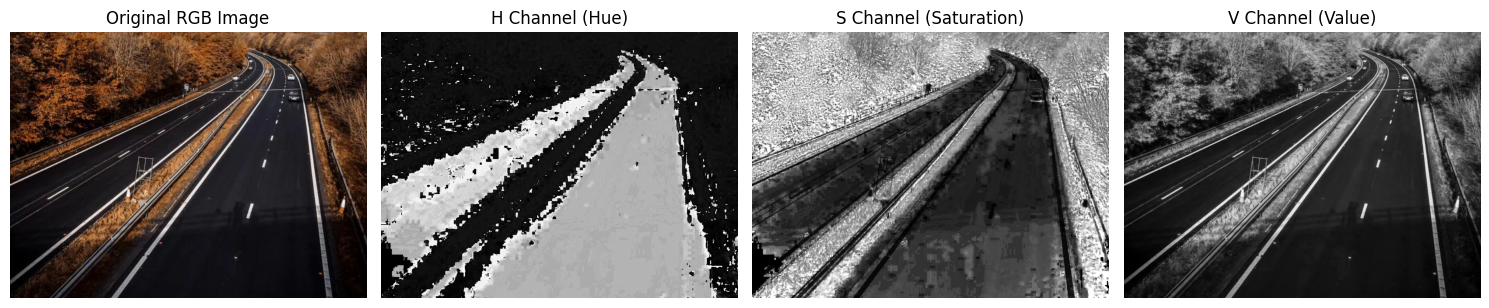

True

In [ ]:
import cv2
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import numpy as np

# 讀取圖片
img_bgr = cv2.imread("road3.png")

# 檢查圖片是否成功載入
if img_bgr is None:
    raise FileNotFoundError("圖片載入失敗，請確認路徑或檔案名稱是否正確。")

# 將 BGR 轉換為 RGB (matplotlib 預設顯示 RGB)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# 將 RGB 圖片轉換為 HSV
img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)

# 分離 HSV 通道
h_channel, s_channel, v_channel = cv2.split(img_hsv)

# 顯示結果
plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.title("Original RGB Image")
plt.imshow(img_rgb)
plt.axis('off')

plt.subplot(1, 4, 2)
plt.title("H Channel (Hue)")
plt.imshow(h_channel, cmap='gray')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.title("S Channel (Saturation)")
plt.imshow(s_channel, cmap='gray')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.title("V Channel (Value)")
plt.imshow(v_channel, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

cv2.imwrite('s_channel.png', s_channel)
cv2.imwrite('h_channel.png', h_channel)

HSV-Histogram

Converged


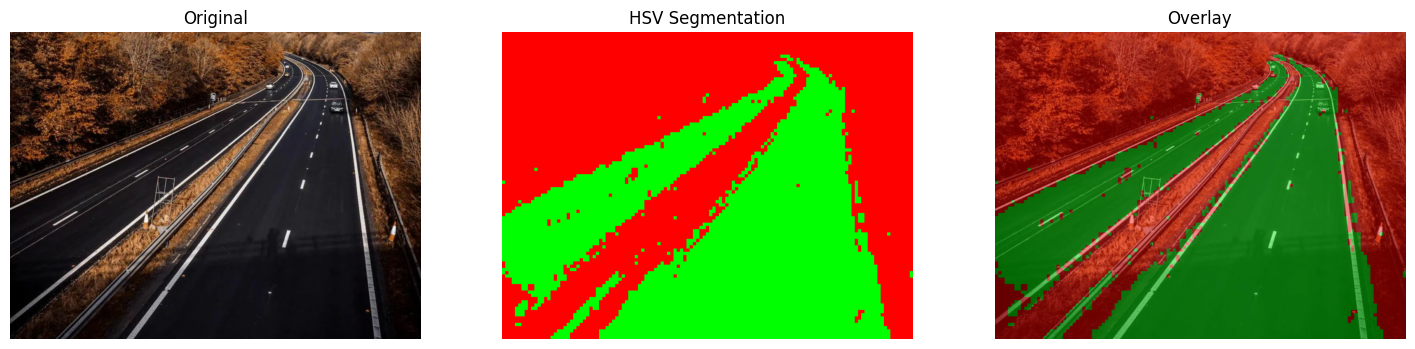

In [4]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# =========================
# 參數
# =========================
image_path = "road3.png"
n_clusters = 2
block_size = 8

# histogram bin 設定（很重要）
h_bins = 2
s_bins = 2
v_bins = 2

epsilon = 1e-8
max_iter = 30
np.random.seed(42)

# =========================
# KL divergence
# =========================
def kl_divergence(p, q):
    p = p + epsilon
    q = q + epsilon
    p = p / p.sum()
    q = q / q.sum()
    return np.sum(p * np.log(p / q))

def hsv_distance(h1, s1, v1, h2, s2, v2):
    return (
        kl_divergence(h1, h2) +
        kl_divergence(s1, s2) +
        kl_divergence(v1, v2)
    )

# =========================
# block histogram
# =========================
def blockwise_hsv_hist(hsv_img, block_size):
    H, W, _ = hsv_img.shape
    H = (H // block_size) * block_size
    W = (W // block_size) * block_size
    hsv_img = hsv_img[:H, :W]

    hist_h_all, hist_s_all, hist_v_all = [], [], []
    coords = []

    for y in range(0, H, block_size):
        for x in range(0, W, block_size):

            block = hsv_img[y:y+block_size, x:x+block_size]

            Hc = block[:, :, 0]
            Sc = block[:, :, 1]
            Vc = block[:, :, 2]

            hist_h, _ = np.histogram(Hc, bins=h_bins, range=(0,180))
            hist_s, _ = np.histogram(Sc, bins=s_bins, range=(0,256))
            hist_v, _ = np.histogram(Vc, bins=v_bins, range=(0,256))

            hist_h = hist_h.astype(np.float64) + epsilon
            hist_s = hist_s.astype(np.float64) + epsilon
            hist_v = hist_v.astype(np.float64) + epsilon

            hist_h /= hist_h.sum()
            hist_s /= hist_s.sum()
            hist_v /= hist_v.sum()

            hist_h_all.append(hist_h)
            hist_s_all.append(hist_s)
            hist_v_all.append(hist_v)
            coords.append((y, x))

    return np.array(hist_h_all), np.array(hist_s_all), np.array(hist_v_all), coords, H, W

# =========================
# clustering
# =========================
def kmeans_hsv(hist_h, hist_s, hist_v, k=5):
    N = len(hist_h)
    idx = np.random.choice(N, k, replace=False)

    centers_h = hist_h[idx]
    centers_s = hist_s[idx]
    centers_v = hist_v[idx]

    labels = np.zeros(N)

    for it in range(max_iter):
        old_labels = labels.copy()

        # assign
        for i in range(N):
            dists = []
            for j in range(k):
                d = hsv_distance(
                    hist_h[i], hist_s[i], hist_v[i],
                    centers_h[j], centers_s[j], centers_v[j]
                )
                dists.append(d)
            labels[i] = np.argmin(dists)

        # update
        new_h, new_s, new_v = [], [], []

        for j in range(k):
            idx = np.where(labels == j)[0]

            if len(idx) == 0:
                rand = np.random.randint(0, N)
                new_h.append(hist_h[rand])
                new_s.append(hist_s[rand])
                new_v.append(hist_v[rand])
            else:
                h = hist_h[idx].mean(axis=0)
                s = hist_s[idx].mean(axis=0)
                v = hist_v[idx].mean(axis=0)

                h /= h.sum()
                s /= s.sum()
                v /= v.sum()

                new_h.append(h)
                new_s.append(s)
                new_v.append(v)

        centers_h = np.array(new_h)
        centers_s = np.array(new_s)
        centers_v = np.array(new_v)

        if np.all(labels == old_labels):
            print("Converged")
            break

    return labels.astype(int)

# =========================
# main
# =========================
img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# histogram
hist_h, hist_s, hist_v, coords, H, W = blockwise_hsv_hist(hsv, block_size)

# clustering
labels = kmeans_hsv(hist_h, hist_s, hist_v, n_clusters)

# label map
label_map = np.zeros((H, W), dtype=np.int32)

i = 0
for y, x in coords:
    label_map[y:y+block_size, x:x+block_size] = labels[i]
    i += 1

# 顏色
colors = np.array([
    [255,0,0],
    [0,255,0],
    [0,0,255],
    [255,255,0],
    [255,0,255],
    [0,255,255]
], dtype=np.uint8)

color_seg = np.zeros((H, W, 3), dtype=np.uint8)
for i in range(n_clusters):
    color_seg[label_map == i] = colors[i]

overlay = cv2.addWeighted(img_rgb[:H,:W], 0.6, color_seg, 0.4, 0)

# 顯示
plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(img_rgb)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("HSV Segmentation")
plt.imshow(color_seg)
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Overlay")
plt.imshow(overlay)
plt.axis("off")

plt.show()

## ex2: LBP-Histogram

In [ ]:
import numpy as np
import cv2
from skimage.feature import local_binary_pattern
import matplotlib.pyplot as plt

# 參數
image_path = "h_channel.png"
n_clusters = 2
block_size = 16

radius = 1
n_points = 8 * radius
method = 'uniform'

epsilon = 1e-8
max_iter = 30
def compute_lbp(gray):
    return local_binary_pattern(gray, n_points, radius, method=method)

def get_num_bins():
    if method == 'uniform':
        return n_points + 2
    else:
        return 2 ** n_points

def blockwise_hist(lbp):
    h, w = lbp.shape
    h = (h // block_size) * block_size
    w = (w // block_size) * block_size
    lbp = lbp[:h, :w]

    histograms = []
    coords = []

    num_bins = get_num_bins()

    for y in range(0, h, block_size):
        for x in range(0, w, block_size):
            block = lbp[y:y+block_size, x:x+block_size]

            hist, _ = np.histogram(
                block.ravel(),
                bins=np.arange(num_bins + 1),
                range=(0, num_bins)
            )

            hist = hist.astype(np.float64)
            hist += epsilon
            hist /= hist.sum()

            histograms.append(hist)
            coords.append((y, x))

    return np.array(histograms), coords, h, w


def kl_divergence(p, q):
    return np.sum(p * np.log(p / q))


def kl_kmeans(histograms, k=5):
    N = len(histograms)
    idx = np.random.choice(N, k, replace=False)
    centers = histograms[idx]

    labels = np.zeros(N)

    for it in range(max_iter):
        # assign
        for i in range(N):
            dists = [kl_divergence(histograms[i], c) for c in centers]
            labels[i] = np.argmin(dists)

        # update
        new_centers = []
        for j in range(k):
            cluster = histograms[labels == j]

            if len(cluster) == 0:
                new_centers.append(histograms[np.random.randint(N)])
            else:
                c = cluster.mean(axis=0)
                c += epsilon
                c /= c.sum()
                new_centers.append(c)

        new_centers = np.array(new_centers)

        if np.allclose(new_centers, centers):
            break

        centers = new_centers

    return labels.astype(int)

# 讀圖、灰階、高斯
img = cv2.imread(image_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

#gaus = cv2.GaussianBlur(gray, (3, 3), 0)

# LBP
lbp = compute_lbp(gray)

# Histogram
hists, coords, H, W = blockwise_hist(lbp)

# KL clustering
labels = kl_kmeans(hists, n_clusters)

# 建立 label map
label_map = np.zeros((H, W), dtype=np.int32)

i = 0
for y, x in coords:
    label_map[y:y+block_size, x:x+block_size] = labels[i]
    i += 1

# 顏色表
colors = np.array([
    [255, 0, 0],
    [0, 255, 0],
    [0, 0, 255],
    [255, 255, 0],
    [255, 0, 255]
], dtype=np.uint8)

color_seg = np.zeros((H, W, 3), dtype=np.uint8)

for i in range(n_clusters):
    color_seg[label_map == i] = colors[i]

# overlay
overlay = cv2.addWeighted(img[:H, :W], 0.6, color_seg, 0.4, 0)

# 顯示
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1,3,2)
plt.title("LBP")
plt.imshow(lbp, cmap='gray')
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Segmentation")
plt.imshow(overlay[:,:,::-1])
plt.axis("off")

plt.show()